<a href="https://www.kaggle.com/code/izzarsulynashrudin/pcqm4mv2?scriptVersionId=309305642" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Pra-pemrosesan dan Pengenalan Dataset PCQM4Mv2 untuk Data Mining Awal

Notebook ini disusun untuk tugas UTS dengan fokus pada **pengelolaan data awal** saja, tanpa tahap klasifikasi, training, atau evaluasi model.

## Tujuan notebook
1. Mengenali struktur dataset PCQM4Mv2
2. Membaca data mentah dalam bentuk SMILES dan graph
3. Memahami fitur atom dan bond
4. Mengubah data graph menjadi bentuk tabular
5. Membuat ringkasan graph per molekul
6. Menampilkan visualisasi molekul 2D
7. Menampilkan visualisasi molekul 3D hasil embedding RDKit

## Catatan penting
- Dataset PCQM4Mv2 yang dipakai di sini berbasis **SMILES dan graph 2D**
- Visualisasi 3D pada notebook ini **dibangkitkan dari SMILES menggunakan RDKit**, sehingga dipakai untuk keperluan eksplorasi awal
- Notebook ini sengaja berhenti pada tahap **preprocessing, eksplorasi awal, dan konversi data**

## Proses 0 — Instalasi pustaka

### Penjelasan
Tahap pertama adalah memasang library yang diperlukan untuk:
- memuat dataset resmi dari OGB,
- mengelola data tabular dengan pandas,
- membuat progress bar,
- memvisualisasikan molekul 2D,
- membangun visualisasi molekul 3D dari SMILES.

### Library yang digunakan
- **ogb**: akses dataset PCQM4Mv2
- **pandas** dan **numpy**: manipulasi data
- **tqdm**: progress bar
- **matplotlib**: visualisasi 2D/3D sederhana
- **rdkit**: parsing SMILES, gambar struktur 2D, dan pembentukan konformer 3D

Jalankan cell berikut satu kali jika library belum terpasang.

In [1]:
import importlib
import subprocess
import sys

def ensure_package(import_name, pip_name=None):
    pip_name = pip_name or import_name
    try:
        importlib.import_module(import_name)
        print(f"{pip_name} sudah tersedia.")
    except ModuleNotFoundError:
        print(f"Memasang {pip_name} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])

ensure_package("ogb")
ensure_package("rdkit")

Memasang ogb ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 4.3 MB/s eta 0:00:00
Memasang rdkit ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 49.7 MB/s eta 0:00:00


## Proses 1 — Import library dan konfigurasi awal

### Penjelasan
Pada tahap ini kita memuat seluruh modul yang dibutuhkan dan membuat folder output.
Folder output akan dipakai untuk menyimpan:
- tabel molekul,
- tabel atom,
- tabel bond,
- ringkasan graph,
- gambar visualisasi,
- dan file JSON ringkasan.

Dengan struktur seperti ini, hasil preprocessing akan lebih rapi dan mudah dikumpulkan.

In [2]:
import os
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display
from mpl_toolkits.mplot3d import Axes3D

import torch
import os.path as osp

try:
    from rdkit import Chem
    from rdkit.Chem import Draw, AllChem
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "rdkit belum terpasang. Jalankan dulu cell 'Proses 0 — Instalasi pustaka'."
    ) from e

try:
    from ogb.lsc import PCQM4Mv2Dataset
    from ogb.utils import smiles2graph
    from ogb.utils.features import (
        allowable_features,
        atom_feature_vector_to_dict,
        bond_feature_vector_to_dict,
    )
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        "ogb belum terpasang. Jalankan dulu cell 'Proses 0 — Instalasi pustaka'."
    ) from e

def normalize_root_candidate(path):
    path = Path(path)

    if (path / "pcqm4m-v2" / "raw" / "data.csv.gz").exists():
        return path

    if path.name == "pcqm4m-v2" and (path / "raw" / "data.csv.gz").exists():
        return path.parent

    return None

def detect_pcqm4mv2_root():
    env_root = os.environ.get("PCQM4MV2_ROOT")

    candidate_roots = []
    if env_root:
        candidate_roots.extend([Path(env_root), Path(env_root).parent])

    candidate_roots.extend([
        Path("/kaggle/input"),
        Path("/kaggle/working"),
        Path.cwd(),
        Path("dataset"),
    ])

    for root in candidate_roots:
        normalized = normalize_root_candidate(root)
        if normalized is not None:
            return str(normalized)

    search_bases = [Path("/kaggle/input"), Path("/kaggle/working"), Path.cwd()]
    if env_root:
        search_bases.insert(0, Path(env_root))

    for base in search_bases:
        if base.exists():
            matches = list(base.rglob("pcqm4m-v2/raw/data.csv.gz"))
            if matches:
                return str(matches[0].parents[2])

    return "dataset"

# Patch untuk PyTorch 2.6+:
# OGB memanggil torch.load(split_dict.pt) tanpa weights_only=False,
# padahal default baru PyTorch 2.6 adalah weights_only=True.
# Akibatnya split_dict.pt gagal dibaca.
def patched_get_idx_split(self):
    split_path = Path(self.folder) / "split_dict.pt"
    if not split_path.exists():
        raise FileNotFoundError(f"split_dict.pt tidak ditemukan di {split_path}")
    return torch.load(split_path, weights_only=False)

PCQM4Mv2Dataset.get_idx_split = patched_get_idx_split

ROOT = detect_pcqm4mv2_root()
OUTDIR = "hasil_pcqm4mv2"
os.makedirs(OUTDIR, exist_ok=True)

print("ROOT terdeteksi:", ROOT)
print("Folder output  :", OUTDIR)

expected_file = Path(ROOT) / "pcqm4m-v2" / "raw" / "data.csv.gz"
print("Raw file ada?  :", expected_file.exists())
if not expected_file.exists():
    print("\nPERINGATAN:")
    print("- File raw PCQM4Mv2 belum terdeteksi di ROOT ini.")
    print("- Jika dataset ada di lokasi lain, set env var PCQM4MV2_ROOT ke folder yang tepat.")
    print("- Jika menjalankan di Kaggle tanpa internet, attach dulu dataset PCQM4Mv2 sebagai input.")
    print("- Jika mengandalkan download otomatis OGB, pastikan internet notebook aktif.")

ROOT terdeteksi: dataset
Folder output  : hasil_pcqm4mv2
Raw file ada?  : False

PERINGATAN:
- File raw PCQM4Mv2 belum terdeteksi di ROOT ini.
- Jika dataset ada di lokasi lain, set env var PCQM4MV2_ROOT ke folder yang tepat.
- Jika menjalankan di Kaggle tanpa internet, attach dulu dataset PCQM4Mv2 sebagai input.
- Jika mengandalkan download otomatis OGB, pastikan internet notebook aktif.


## Proses 2 — Load dataset PCQM4Mv2

### Penjelasan
Tahap ini bertujuan untuk memuat dataset dari OGB dan membaca pembagian data resmi (**split**).

Dataset ini akan diakses menggunakan:
- **SMILES**
- **target**
- **split index**

Parameter `only_smiles=True` dipakai agar data yang diambil lebih ringan dan sesuai untuk eksplorasi awal.
Dengan cara ini kita bisa fokus pada:
- pengenalan data,
- pembacaan fitur graph,
- konversi ke bentuk tabel.

### Mengapa split penting?
Split menunjukkan apakah suatu molekul termasuk:
- training,
- validasi,
- test-dev,
- test-challenge.

Walaupun belum masuk training, informasi split tetap penting sebagai metadata saat menyusun tabel tabular.

In [3]:
try:
    dataset = PCQM4Mv2Dataset(root=ROOT, only_smiles=True)
    split_dict = dataset.get_idx_split()

    print("Jumlah total molekul:", len(dataset))
    print("\nJumlah data per split:")
    for k, v in split_dict.items():
        print(f"{k:15s}: {len(v):,}")

except Exception as e:
    raise RuntimeError(
        "Gagal memuat PCQM4Mv2.\n\n"
        "Checklist perbaikan:\n"
        "1. Pastikan dataset PCQM4Mv2 sudah di-attach sebagai input, atau internet notebook aktif.\n"
        "2. Pastikan ROOT mengarah ke folder yang berisi pcqm4m-v2/raw/data.csv.gz.\n"
        "3. Jika dataset ada di lokasi lain, set env var PCQM4MV2_ROOT ke folder parent dari pcqm4m-v2.\n"
        "4. Jika error menyebut split_dict.pt / weights_only, notebook ini sudah memakai torch-fix.\n\n"
        f"ROOT saat ini: {ROOT}\n"
        f"Raw file terdeteksi: {expected_file.exists()}\n"
        f"Detail error asli: {repr(e)}"
    )

Downloaded 0.06 GB: 100%|██████████| 60/60 [00:02<00:00, 25.82it/s]


Extracting dataset/pcqm4m-v2.zip
Jumlah total molekul: 3746620

Jumlah data per split:
train          : 3,378,606
valid          : 73,545
test-dev       : 147,037
test-challenge : 147,432


## Proses 3 — Membuat label split untuk setiap molekul

### Penjelasan
`split_dict` dari OGB berisi daftar indeks untuk masing-masing subset.
Agar setiap molekul nanti mudah dimasukkan ke tabel, kita buat array `split_arr`
yang menyimpan label split untuk setiap indeks data.

### Tujuan
Setelah langkah ini, setiap molekul ke-`i` bisa langsung diketahui berasal dari split mana.

In [4]:
split_arr = np.array(["unknown"] * len(dataset), dtype=object)

for split_name, idxs in split_dict.items():
    split_arr[np.asarray(idxs, dtype=np.int64)] = split_name

pd.Series(split_arr).value_counts()

train             3378606
test-challenge     147432
test-dev           147037
valid               73545
Name: count, dtype: int64

## Proses 4 — Melihat contoh data mentah

### Penjelasan
Sebelum mengolah seluruh dataset, kita perlu memahami bentuk satu data terlebih dahulu.

Untuk satu indeks sampel, kita akan melihat:
- nilai SMILES,
- target,
- jumlah atom,
- bentuk matriks fitur atom,
- bentuk matriks fitur bond,
- bentuk edge index.

### Mengapa perlu?
Langkah ini penting agar kita memahami struktur data sebelum melakukan konversi massal ke tabel.

In [5]:
sample_idx = min(10, len(dataset) - 1)

smiles, y = dataset[sample_idx]
graph = smiles2graph(smiles)

print("Index         :", sample_idx)
print("Split         :", split_arr[sample_idx])
print("SMILES        :", smiles)
print("Target y      :", y)
print("Jumlah node   :", graph["num_nodes"])
print("Shape nodefeat:", graph["node_feat"].shape)
print("Shape edgefeat:", graph["edge_feat"].shape)
print("Shape edge_idx:", graph["edge_index"].shape)

Index         : 10
Split         : train
SMILES        : CCCN1[C@@H](Cl)[C@@H](N(=O)=O)C(=NC1=O)O
Target y      : 4.174226466670001
Jumlah node   : 15
Shape nodefeat: (15, 9)
Shape edgefeat: (30, 3)
Shape edge_idx: (2, 30)


## Proses 5 — Mendokumentasikan skema fitur atom dan bond

### Penjelasan
Fitur graph dari OGB pada awalnya berbentuk angka encoded.
Supaya lebih mudah dibaca dan dijelaskan dalam laporan, kita dokumentasikan nama fitur atom dan bond.

### Fitur atom
1. `atomic_num`
2. `chirality`
3. `degree`
4. `formal_charge`
5. `num_h`
6. `num_rad_e`
7. `hybridization`
8. `is_aromatic`
9. `is_in_ring`

### Fitur bond
1. `bond_type`
2. `bond_stereo`
3. `is_conjugated`

Skema ini juga akan disimpan ke file JSON agar dapat dipakai sebagai dokumentasi dataset.

In [6]:
ATOM_FEATURE_ORDER = [
    "atomic_num",
    "chirality",
    "degree",
    "formal_charge",
    "num_h",
    "num_rad_e",
    "hybridization",
    "is_aromatic",
    "is_in_ring",
]

BOND_FEATURE_ORDER = [
    "bond_type",
    "bond_stereo",
    "is_conjugated",
]

feature_schema = {
    "atom_feature_order": ATOM_FEATURE_ORDER,
    "bond_feature_order": BOND_FEATURE_ORDER,
    "allowable_features": allowable_features,
}

schema_path = os.path.join(OUTDIR, "feature_schema.json")
with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, indent=2, ensure_ascii=False)

print("Feature schema tersimpan di:", schema_path)

Feature schema tersimpan di: hasil_pcqm4mv2/feature_schema.json


## Proses 6 — Membuat tabel molekul (1 baris = 1 molekul)

### Penjelasan
Tahap ini mengubah data mentah menjadi bentuk tabular tingkat molekul.

### Kolom yang dibuat
- `molecule_id`: indeks unik molekul
- `split`: asal subset data
- `smiles`: representasi string molekul
- `smiles_length`: panjang string SMILES
- `target_homo_lumo_gap`: target jika tersedia
- `target_available`: penanda ada/tidaknya target

### Mengapa penting?
Walaupun data asli berbentuk graph, analisis awal jauh lebih mudah dilakukan jika tersedia tabel molekul.
Tabel ini berguna untuk:
- statistik dasar,
- pengecekan jumlah data,
- melihat kelengkapan label,
- dan dokumentasi awal.

In [7]:
def to_scalar_label(y):
    if isinstance(y, np.ndarray):
        if y.size == 0:
            return np.nan
        y = y.reshape(-1)[0]
    if pd.isna(y):
        return np.nan
    return float(y)

def build_molecule_table(dataset, split_arr, limit=50000):
    rows = []
    n = len(dataset) if limit == -1 else min(limit, len(dataset))

    for i in tqdm(range(n), desc="Molecule table"):
        smiles, y = dataset[i]
        y_val = to_scalar_label(y)

        rows.append({
            "molecule_id": i,
            "split": split_arr[i],
            "smiles": smiles,
            "smiles_length": len(smiles),
            "target_homo_lumo_gap": y_val,
            "target_available": not pd.isna(y_val)
        })

    return pd.DataFrame(rows)

molecule_df = build_molecule_table(dataset, split_arr, limit=50000)
molecule_df.head()

Molecule table: 100%|██████████| 50000/50000 [00:00<00:00, 379013.19it/s]


,molecule_id,split,smiles,smiles_length,target_homo_lumo_gap,target_available
0,0,train,O=C1[N]c2ccncc2[CH][C@@H]1c1ccc(cc1)C,37,3.047675,True
1,1,train,COc1cc(OC)ccc1/C=C/N(C(=O)C)C,29,4.410966,True
2,2,train,C=CCN(C(=O)C)/C=C/c1ccccc1C,27,4.639541,True
3,3,train,C=CCN(C(=O)C)/C=C/c1ccccc1F,27,4.492600,True
4,4,train,C=CCN(C(=O)C)/C=C/c1ccccc1Cl,28,4.612330,True


In [8]:
molecule_csv = os.path.join(OUTDIR, "molecule_table.csv")
molecule_df.to_csv(molecule_csv, index=False)
print("Tabel molekul tersimpan di:", molecule_csv)

Tabel molekul tersimpan di: hasil_pcqm4mv2/molecule_table.csv


## Proses 7 — Mengubah graph menjadi tabel atom (1 baris = 1 atom)

### Penjelasan
Pada tahap ini setiap atom dari suatu molekul dijadikan satu baris data.

### Mengapa perlu?
Graph molekul menyimpan atom sebagai node dengan vektor fitur.
Agar fitur tersebut bisa dianalisis menggunakan pendekatan tabular, setiap atom perlu diubah menjadi baris tabel.

### Isi tabel atom
Setiap baris berisi:
- `molecule_id`
- `atom_id`
- seluruh fitur atom yang sudah didecode

Langkah ini berguna untuk analisis seperti:
- frekuensi atom,
- proporsi atom aromatik,
- distribusi degree,
- dan karakteristik atom lain.

In [9]:
def graph_to_atom_table(smiles, molecule_id):
    graph = smiles2graph(smiles)
    node_feat = graph["node_feat"]

    rows = []
    for atom_id, feat in enumerate(node_feat):
        decoded = atom_feature_vector_to_dict(feat.tolist())
        rows.append({
            "molecule_id": molecule_id,
            "atom_id": atom_id,
            **decoded
        })
    return pd.DataFrame(rows)

atom_df_sample = graph_to_atom_table(smiles, sample_idx)
atom_df_sample.head()

,molecule_id,atom_id,atomic_num,chirality,degree,formal_charge,num_h,num_rad_e,hybridization,is_aromatic,is_in_ring
0,10,0,6,CHI_UNSPECIFIED,4,0,3,0,SP3,False,False
1,10,1,6,CHI_UNSPECIFIED,4,0,2,0,SP3,False,False
2,10,2,6,CHI_UNSPECIFIED,4,0,2,0,SP3,False,False
3,10,3,7,CHI_UNSPECIFIED,3,0,0,0,SP2,False,True
4,10,4,6,CHI_TETRAHEDRAL_CW,4,0,1,0,SP3,False,True


## Proses 8 — Mengubah graph menjadi tabel bond (1 baris = 1 bond unik)

### Penjelasan
Selain atom, kita juga perlu menyusun tabel untuk ikatan antar atom.

### Hal penting
Pada representasi graph OGB, edge biasanya tersimpan dalam dua arah:
- atom A ke atom B
- atom B ke atom A

Karena yang kita butuhkan adalah **bond unik**, maka pasangan edge dua arah harus digabung
agar tidak terjadi duplikasi.

### Isi tabel bond
- `molecule_id`
- `src_atom_id`
- `dst_atom_id`
- `bond_type`
- `bond_stereo`
- `is_conjugated`

In [10]:
def graph_to_bond_table(smiles, molecule_id):
    graph = smiles2graph(smiles)
    edge_index = graph["edge_index"]
    edge_feat = graph["edge_feat"]

    rows = []
    seen = set()

    for col in range(edge_index.shape[1]):
        src = int(edge_index[0, col])
        dst = int(edge_index[1, col])
        a, b = sorted((src, dst))

        if (a, b) in seen:
            continue
        seen.add((a, b))

        decoded = bond_feature_vector_to_dict(edge_feat[col].tolist())
        rows.append({
            "molecule_id": molecule_id,
            "src_atom_id": a,
            "dst_atom_id": b,
            **decoded
        })

    return pd.DataFrame(rows)

bond_df_sample = graph_to_bond_table(smiles, sample_idx)
bond_df_sample.head()

,molecule_id,src_atom_id,dst_atom_id,bond_type,bond_stereo,is_conjugated
0,10,0,1,SINGLE,STEREONONE,False
1,10,1,2,SINGLE,STEREONONE,False
2,10,2,3,SINGLE,STEREONONE,False
3,10,3,4,SINGLE,STEREONONE,False
4,10,4,5,SINGLE,STEREONONE,False


## Proses 9 — Membuat ringkasan graph per molekul

### Penjelasan
Tahap ini menghasilkan tabel ringkasan struktur graph untuk tiap molekul.

### Fitur ringkasan yang dihitung
- jumlah atom,
- jumlah edge terarah,
- jumlah bond unik,
- jumlah atom aromatik,
- jumlah atom yang berada dalam ring.

### Mengapa penting?
Ringkasan ini sangat membantu untuk:
- memahami kompleksitas molekul,
- membandingkan molekul satu dengan yang lain,
- dan menyiapkan data untuk eksplorasi lanjutan.

In [11]:
def graph_summary(smiles, molecule_id, split_name, y):
    graph = smiles2graph(smiles)
    node_feat = graph["node_feat"]
    edge_index = graph["edge_index"]

    aromatic_count = 0
    ring_count = 0

    for feat in node_feat:
        decoded = atom_feature_vector_to_dict(feat.tolist())
        if decoded["is_aromatic"]:
            aromatic_count += 1
        if decoded["is_in_ring"]:
            ring_count += 1

    y_val = to_scalar_label(y)

    return {
        "molecule_id": molecule_id,
        "split": split_name,
        "smiles": smiles,
        "target_homo_lumo_gap": y_val,
        "num_nodes": int(graph["num_nodes"]),
        "num_edges_directed": int(edge_index.shape[1]),
        "num_bonds_undirected": int(edge_index.shape[1] // 2),
        "num_aromatic_atoms": aromatic_count,
        "num_ring_atoms": ring_count,
    }

summary_row = graph_summary(smiles, sample_idx, split_arr[sample_idx], y)
pd.DataFrame([summary_row])

,molecule_id,split,smiles,target_homo_lumo_gap,num_nodes,num_edges_directed,num_bonds_undirected,num_aromatic_atoms,num_ring_atoms
0,10,train,CCCN1[C@@H](Cl)[C@@H](N(=O)=O)C(=NC1=O)O,4.174226,15,30,15,0,6


## Proses 10 — Batch konversi beberapa molekul ke tabel atom, bond, dan ringkasan graph

### Penjelasan
Karena dataset PCQM4Mv2 sangat besar, pada tahap awal kita tidak harus langsung memproses semuanya.
Kita bisa mulai dari 1000 molekul agar:
- proses lebih ringan,
- notebook tetap responsif,
- dan alur preprocessing tetap bisa ditunjukkan dengan jelas.

### Output
- `atom_df`
- `bond_df`
- `summary_df`

Ketiga tabel ini merupakan hasil utama dari preprocessing graph ke bentuk tabular.

In [12]:
def build_atom_bond_tables(dataset, split_arr, limit=1000):
    atom_frames = []
    bond_frames = []
    summary_rows = []

    n = len(dataset) if limit == -1 else min(limit, len(dataset))

    for i in tqdm(range(n), desc="Atom/Bond tables"):
        smiles, y = dataset[i]

        atom_frames.append(graph_to_atom_table(smiles, i))
        bond_frames.append(graph_to_bond_table(smiles, i))
        summary_rows.append(graph_summary(smiles, i, split_arr[i], y))

    atom_df = pd.concat(atom_frames, ignore_index=True)
    bond_df = pd.concat(bond_frames, ignore_index=True)
    summary_df = pd.DataFrame(summary_rows)

    return atom_df, bond_df, summary_df

atom_df, bond_df, summary_df = build_atom_bond_tables(dataset, split_arr, limit=1000)

print("Ukuran atom_df   :", atom_df.shape)
print("Ukuran bond_df   :", bond_df.shape)
print("Ukuran summary_df:", summary_df.shape)

Atom/Bond tables: 100%|██████████| 1000/1000 [00:02<00:00, 430.10it/s]


Ukuran atom_df   : (15089, 11)
Ukuran bond_df   : (15642, 6)
Ukuran summary_df: (1000, 9)


In [13]:
atom_csv = os.path.join(OUTDIR, "atom_table.csv")
bond_csv = os.path.join(OUTDIR, "bond_table.csv")
summary_csv = os.path.join(OUTDIR, "graph_summary_table.csv")

atom_df.to_csv(atom_csv, index=False)
bond_df.to_csv(bond_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("File tersimpan:")
print("-", atom_csv)
print("-", bond_csv)
print("-", summary_csv)

File tersimpan:
- hasil_pcqm4mv2/atom_table.csv
- hasil_pcqm4mv2/bond_table.csv
- hasil_pcqm4mv2/graph_summary_table.csv


## Proses 11 — Memilih sampel molekul yang baik untuk visualisasi

### Penjelasan
Tidak semua molekul cocok langsung ditampilkan.
Agar visualisasi lebih informatif, kita pilih molekul dengan beberapa kriteria:
- target tersedia,
- tidak terdiri dari banyak fragmen terpisah,
- berhasil diparse oleh RDKit,
- ukuran atom tidak terlalu kecil dan tidak terlalu besar.

### Tujuan
Sampel yang dipilih akan dipakai untuk:
- visualisasi 2D,
- visualisasi 3D,
- dan contoh pembahasan di laporan.

In [14]:
def pick_good_samples(dataset, split_arr, scan_limit=3000, n_samples=6):
    candidates = []

    for i in tqdm(range(min(scan_limit, len(dataset))), desc="Mencari sampel bagus"):
        smiles, y = dataset[i]
        y_val = to_scalar_label(y)

        if pd.isna(y_val):
            continue
        if "." in smiles:
            continue

        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue

        n_atoms = mol.GetNumAtoms()
        if n_atoms < 6 or n_atoms > 45:
            continue

        candidates.append({
            "molecule_id": i,
            "split": split_arr[i],
            "smiles": smiles,
            "target": y_val,
            "num_atoms": n_atoms
        })

    cand_df = pd.DataFrame(candidates)
    if len(cand_df) == 0:
        print("Tidak ada sampel yang lolos filter. Coba perbesar scan_limit.")
        return cand_df

    cand_df = cand_df.sort_values("num_atoms").reset_index(drop=True)
    quantiles = np.linspace(0.1, 0.9, n_samples)
    chosen_idx = sorted(set(int(q * (len(cand_df) - 1)) for q in quantiles))
    chosen_df = cand_df.iloc[chosen_idx].reset_index(drop=True)
    return chosen_df

sample_df = pick_good_samples(dataset, split_arr, scan_limit=3000, n_samples=6)
sample_df

Mencari sampel bagus: 100%|██████████| 3000/3000 [00:00<00:00, 7997.53it/s]


,molecule_id,split,smiles,target,num_atoms
0,2643,train,O=CN(CCC[C@@H](C(=O)O)N)O,7.094008,12
1,1266,train,CC([C@@H](C[C@@H]([C@@H](C(C)C)O)O)O)C,8.258655,13
2,2194,train,O=C1[C@@H]2OCC([C@@H]2N1C(C)(C)C)(C)C,6.715770,14
3,829,train,CCOC(=O)C1=C(CC)C=CC=CC=C1,4.313005,15
4,2241,train,C=C1C=C[C@@H]([C@@H]1c1cccc(c1)C)C(=O)C,5.360643,16
5,1510,train,CC[C@H](/N=C(\C=C\c1cccc(c1)OC)/O)C,4.345658,17


## Proses 12 — Visualisasi molekul 2D

### Penjelasan
Visualisasi 2D dipakai karena bentuk dasar data PCQM4Mv2 memang berasal dari SMILES yang direpresentasikan
sebagai graph 2D.

### Tujuan visualisasi 2D
- melihat struktur dasar molekul,
- membandingkan bentuk antar sampel,
- mengamati ring, cabang, dan pola ikatan secara sederhana.

Setiap gambar akan diberi informasi:
- ID molekul,
- split,
- jumlah atom,
- target.

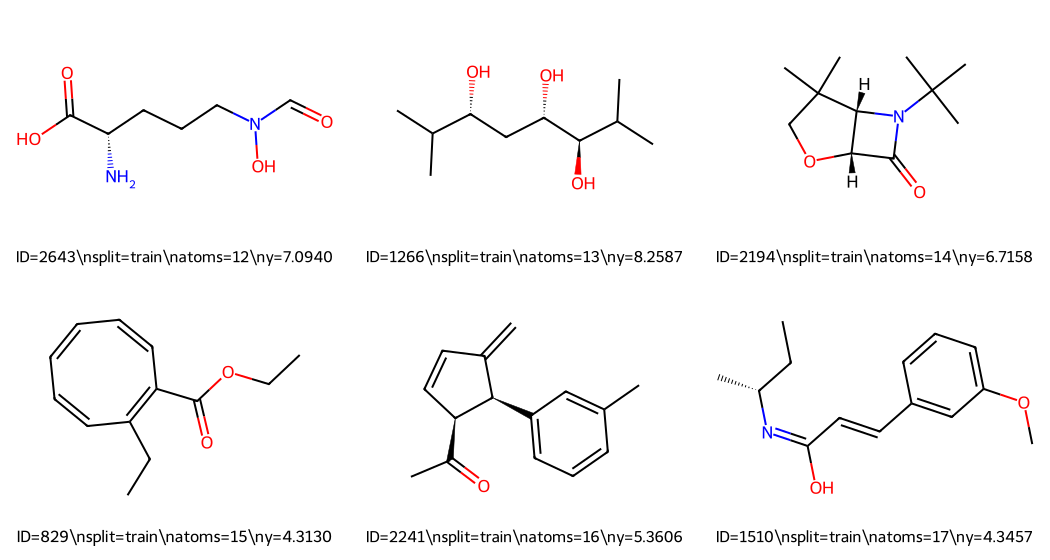

Gambar 2D tersimpan di: hasil_pcqm4mv2/molecule_samples_2d.png


In [15]:
from IPython.display import Image, display
from rdkit.Chem import Draw
from rdkit import Chem
import io
import os

def draw_molecules_2d(sample_df, save_path=None):
    if sample_df.empty:
        raise ValueError("sample_df kosong. Jalankan ulang proses pemilihan sampel dengan scan_limit lebih besar.")

    mols = []
    legends = []

    for _, row in sample_df.iterrows():
        mol = Chem.MolFromSmiles(row["smiles"])
        if mol is None:
            continue

        target_text = "NA" if pd.isna(row["target"]) else f'{float(row["target"]):.4f}'

        mols.append(mol)
        legends.append(
            f'ID={row["molecule_id"]}\\n'
            f'split={row["split"]}\\n'
            f'atoms={row["num_atoms"]}\\n'
            f'y={target_text}'
        )

    if len(mols) == 0:
        raise ValueError("Semua sampel gagal diparse oleh RDKit.")

    grid_img = Draw.MolsToGridImage(
        mols,
        legends=legends,
        molsPerRow=3,
        subImgSize=(350, 280),
        useSVG=False,
    )

    if isinstance(grid_img, (bytes, bytearray)):
        png_data = bytes(grid_img)
        display(Image(data=png_data))
    elif hasattr(grid_img, "save"):
        buffer = io.BytesIO()
        grid_img.save(buffer, format="PNG")
        png_data = buffer.getvalue()
        display(grid_img)
    elif hasattr(grid_img, "data"):
        png_data = grid_img.data
        display(grid_img)
    else:
        raise TypeError(f"Tipe output RDKit tidak dikenali: {type(grid_img)}")

    if save_path is not None:
        with open(save_path, "wb") as f:
            f.write(png_data)
        print("Gambar 2D tersimpan di:", save_path)

draw_molecules_2d(
    sample_df,
    save_path=os.path.join(OUTDIR, "molecule_samples_2d.png")
)

## Proses 13 — Membangun struktur 3D dari SMILES menggunakan RDKit

### Penjelasan
Dataset yang dipakai di notebook ini berbasis graph 2D, sehingga untuk visualisasi 3D
kita membangkitkan **konformer 3D** dari SMILES menggunakan RDKit.

### Alur pembentukan 3D
1. SMILES diparse menjadi objek molekul
2. Hidrogen eksplisit ditambahkan
3. Konformer 3D dibangkitkan
4. Geometri dioptimasi secara kasar

### Catatan
Visualisasi 3D ini digunakan untuk **eksplorasi struktur**, bukan sebagai koordinat 3D resmi bawaan dataset.

In [16]:
def build_3d_mol_from_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mol = Chem.AddHs(mol)

    params = AllChem.ETKDGv2()
    params.randomSeed = 42

    status = AllChem.EmbedMolecule(mol, params)
    if status != 0:
        return None

    try:
        AllChem.UFFOptimizeMolecule(mol)
    except:
        pass

    return mol

## Proses 14 — Visualisasi molekul 3D dengan matplotlib

### Penjelasan
Pada tahap ini koordinat 3D dari konformer RDKit akan digambar menggunakan matplotlib 3D.

### Yang ditampilkan
- atom sebagai titik,
- simbol atom sebagai label,
- bond sebagai garis penghubung.

### Tujuan
Visualisasi ini membantu melihat bentuk spasial molekul secara intuitif.

In [17]:
def plot_molecule_3d(mol, title="Molecule 3D"):
    conf = mol.GetConformer()

    coords = []
    symbols = []

    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        coords.append([pos.x, pos.y, pos.z])
        symbols.append(atom.GetSymbol())

    coords = np.array(coords)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        xs = [coords[i, 0], coords[j, 0]]
        ys = [coords[i, 1], coords[j, 1]]
        zs = [coords[i, 2], coords[j, 2]]
        ax.plot(xs, ys, zs, linewidth=1.5)

    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=120)

    for i, (x, y, z) in enumerate(coords):
        ax.text(x, y, z, symbols[i], fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

## Proses 15 — Menampilkan beberapa contoh molekul 3D

### Penjelasan
Tiga sampel awal dari `sample_df` akan divisualisasikan dalam bentuk 3D.
Langkah ini cukup untuk menunjukkan variasi bentuk spasial molekul tanpa membuat notebook terlalu berat.

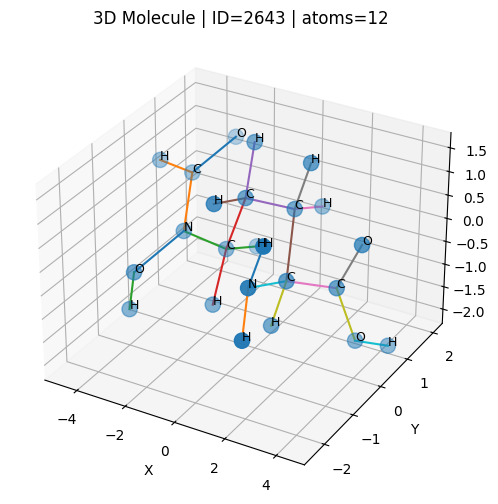

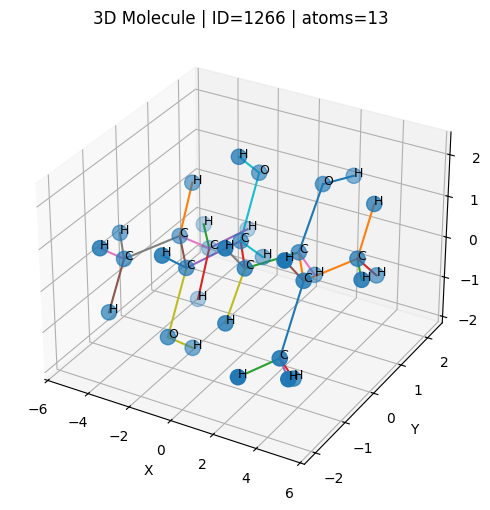

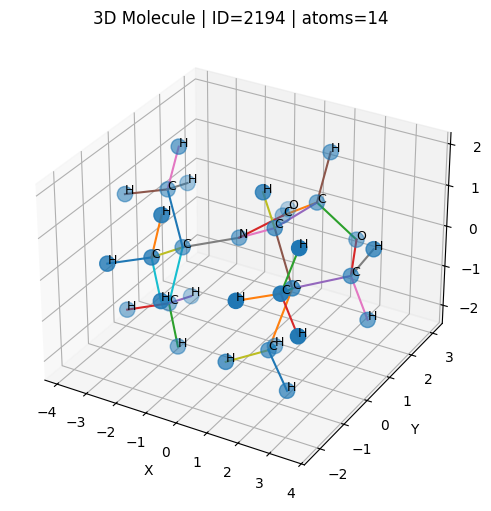

In [18]:
for _, row in sample_df.head(3).iterrows():
    mol3d = build_3d_mol_from_smiles(row["smiles"])
    if mol3d is not None:
        plot_molecule_3d(
            mol3d,
            title=f'3D Molecule | ID={row["molecule_id"]} | atoms={row["num_atoms"]}'
        )

## Proses 16 — Menyimpan gambar 3D ke file PNG

### Penjelasan
Agar hasil 3D bisa dipakai untuk laporan atau presentasi, kita simpan visualisasinya ke file gambar.
Dengan begitu hasil eksplorasi tidak hanya tampil di notebook, tetapi juga tersedia sebagai artefak terpisah.

In [19]:
def save_molecule_3d_png(mol, save_path, title="Molecule 3D"):
    conf = mol.GetConformer()

    coords = []
    symbols = []

    for atom in mol.GetAtoms():
        pos = conf.GetAtomPosition(atom.GetIdx())
        coords.append([pos.x, pos.y, pos.z])
        symbols.append(atom.GetSymbol())

    coords = np.array(coords)

    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection="3d")

    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            [coords[i, 2], coords[j, 2]],
            linewidth=1.5
        )

    ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], s=120)

    for i, (x, y, z) in enumerate(coords):
        ax.text(x, y, z, symbols[i], fontsize=9)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    plt.tight_layout()
    plt.savefig(save_path, dpi=200)
    plt.close()

for _, row in sample_df.head(3).iterrows():
    mol3d = build_3d_mol_from_smiles(row["smiles"])
    if mol3d is not None:
        save_path = os.path.join(OUTDIR, f'molecule_3d_{row["molecule_id"]}.png')
        save_molecule_3d_png(
            mol3d,
            save_path=save_path,
            title=f'3D Molecule ID={row["molecule_id"]}'
        )

print("Snapshot 3D selesai disimpan.")

Snapshot 3D selesai disimpan.


## Proses 17 — Ringkasan hasil preprocessing

### Penjelasan
Tahap akhir ini menyusun ringkasan seluruh hasil preprocessing ke dalam file JSON.

### Isi ringkasan
- nama dataset,
- total molekul,
- jumlah data per split,
- jumlah baris pada tabel hasil,
- jumlah sampel visualisasi.

Ringkasan ini memudahkan dokumentasi hasil kerja dan bisa dilampirkan pada laporan UTS.

In [20]:
overview = {
    "dataset_name": "PCQM4Mv2",
    "total_molecules": len(dataset),
    "split_counts": {k: int(len(v)) for k, v in split_dict.items()},
    "molecule_table_rows": int(len(molecule_df)),
    "atom_table_rows": int(len(atom_df)),
    "bond_table_rows": int(len(bond_df)),
    "graph_summary_rows": int(len(summary_df)),
    "sample_visualization_rows": int(len(sample_df)),
}

overview_path = os.path.join(OUTDIR, "dataset_overview.json")
with open(overview_path, "w", encoding="utf-8") as f:
    json.dump(overview, f, indent=2, ensure_ascii=False)

overview

{'dataset_name': 'PCQM4Mv2',
 'total_molecules': 3746620,
 'split_counts': {'train': 3378606,
  'valid': 73545,
  'test-dev': 147037,
  'test-challenge': 147432},
 'molecule_table_rows': 50000,
 'atom_table_rows': 15089,
 'bond_table_rows': 15642,
 'graph_summary_rows': 1000,
 'sample_visualization_rows': 6}

## Proses 18 — Menampilkan file hasil

### Penjelasan
Cell ini menampilkan seluruh file yang berhasil dibuat selama preprocessing.
Dengan begitu kita dapat memastikan semua output tersimpan dengan benar.

In [21]:
for file_name in sorted(os.listdir(OUTDIR)):
    print(file_name)

atom_table.csv
bond_table.csv
dataset_overview.json
feature_schema.json
graph_summary_table.csv
molecule_3d_1266.png
molecule_3d_2194.png
molecule_3d_2643.png
molecule_samples_2d.png
molecule_table.csv


# Kesimpulan

Pada notebook ini telah dilakukan tahap awal pengelolaan data pada dataset PCQM4Mv2, yaitu:
1. memuat dataset dan split resminya,
2. membaca contoh data mentah berbentuk SMILES dan graph,
3. mendokumentasikan fitur atom dan bond,
4. mengubah data ke bentuk tabel molekul,
5. mengubah graph ke tabel atom dan bond,
6. membuat ringkasan graph,
7. menampilkan visualisasi molekul 2D,
8. menampilkan visualisasi molekul 3D hasil embedding RDKit.

Tahapan ini sudah cukup untuk menunjukkan proses **pengenalan data**, **pembacaan fitur**, dan **konversi ke data tabular** yang menjadi inti pengelolaan data awal sebelum masuk ke tahap pemodelan.